In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Libraries**

In [1]:
import re
import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

#**Functions**

In [ ]:
def load_movielens_ratings_1m(path='ml-1m/ratings.dat'):
    ratings = pd.read_csv(path, sep='::', engine='python', names=['userId', 'movieId', 'rating', 'timestamp'], encoding='latin-1')
    ratings = ratings[['userId', 'movieId', 'rating']]

    ratings['userId'] = ratings['userId'].astype(int)
    ratings['movieId'] = ratings['movieId'].astype(int)
    ratings['rating'] = ratings['rating'].astype(float)

    return ratings


def load_movie_titles_1m(path='ml-1m/movies.dat'):
    movies_df = pd.read_csv(path, sep='::', engine='python', encoding='latin-1', names=['movieId', 'title', 'genres'])
    movie_id_to_title = dict(zip(movies_df['movieId'], movies_df['title']))

    return movie_id_to_title


def build_rating_matrix(ratings_df):
    if ratings_df.empty:
        raise ValueError('Ratings dataframe is empty')

    user_item = ratings_df.pivot_table(index='userId', columns='movieId', values='rating', aggfunc='mean')
    observed_mask = ~user_item.isna()
    R = user_item.to_numpy(dtype=float)

    movie_ids = user_item.columns.to_numpy()
    user_ids = user_item.index.to_numpy()
    user_id_to_index = {int(user_id): idx for idx, user_id in enumerate(user_ids)}

    return R, observed_mask.to_numpy(), user_ids, movie_ids, user_id_to_index


def create_train_test_split(R, observed_mask, test_size=0.2, random_state=42):
    observed_indices = np.argwhere(observed_mask)
    if len(observed_indices) < 2:
        raise ValueError('At least two observed ratings are required')
    if not 0 < test_size < 1:
        raise ValueError('test_size must be between 0 and 1')

    _, test_idx = train_test_split(observed_indices, test_size=test_size, random_state=random_state)
    if len(test_idx) == 0:
        raise ValueError('Test set is empty')

    R_train = R.copy()
    train_mask = observed_mask.copy()
    test_entries = []

    for row, col in test_idx:
        test_entries.append((row, col, float(R[row, col])))
        R_train[row, col] = np.nan
        train_mask[row, col] = False
    if not np.any(train_mask):
        raise ValueError('Training set contains no observed ratings')

    return R_train, train_mask, test_entries


def initialize_missing_values(R, method='user'):
    R_filled = R.copy()
    if np.isnan(R_filled).all():
        raise ValueError('Matrix contains only missing values')
    global_mean = np.nanmean(R_filled)
    nan_mask = np.isnan(R_filled)

    if method == 'user':
        means = np.nanmean(R_filled, axis=1)
        means = np.where(np.isnan(means), global_mean, means)
        R_filled[nan_mask] = np.take(means, np.where(nan_mask)[0])

    elif method == 'item':
        means = np.nanmean(R_filled, axis=0)
        means = np.where(np.isnan(means), global_mean, means)
        R_filled[nan_mask] = np.take(means, np.where(nan_mask)[1])

    else:
        raise ValueError("method must be 'user' or 'item'")

    return R_filled.astype(float)


def normalize_matrix(R, method='user'):
    if method not in {'user', 'item'}:
        raise ValueError("method must be 'user' or 'item'")
    global_mean = np.nanmean(R)

    if method == 'user':
        means = np.nanmean(R, axis=1)
        means = np.where(np.isnan(means), global_mean, means)
        R_normalized = R - means[:, np.newaxis]
    else:
        means = np.nanmean(R, axis=0)
        means = np.where(np.isnan(means), global_mean, means)
        R_normalized = R - means[np.newaxis, :]

    return R_normalized, means


def denormalize_matrix(R_normalized, means, method='user'):
    if method == 'user':
        return R_normalized + means[:, np.newaxis]
    elif method == 'item':
        return R_normalized + means[np.newaxis, :]
    else:
        raise ValueError("method must be 'user' or 'item'")


def analyze_singular_values(R_normalized, energy_threshold=0.9, max_k=None):
    min_dimension = min(R_normalized.shape)
    if max_k is None:
        _, singular_values, _ = np.linalg.svd(R_normalized, full_matrices=False)
    else:
        max_k = min(max_k, min_dimension - 1)
        _, singular_values, _ = svds(R_normalized, k=max_k)
        singular_values = np.sort(singular_values)[::-1]

    singular_energy = singular_values ** 2
    cumulative_energy = np.cumsum(singular_energy)
    total_energy = cumulative_energy[-1]
    energy_ratio = cumulative_energy / total_energy
    k = np.searchsorted(energy_ratio,energy_threshold) + 1

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(singular_values) + 1), singular_values)
    plt.xlabel("k")
    plt.ylabel("Singular Value")
    plt.title("Singular Value Spectrum")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(energy_ratio) + 1), energy_ratio)

    plt.axhline(energy_threshold, color='red', linestyle='--', label=f'{energy_threshold*100:.0f}% Energy')
    plt.axvline(k, color='green', linestyle='--', label=f'k = {k}')

    plt.xlabel("k")
    plt.ylabel("Cumulative Energy Ratio")
    plt.title("Captured Energy vs k")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Chosen k = {k}")
    print(f"Captured energy = "f"{energy_ratio[k - 1] * 100:.2f}%")

    return k


def compute_truncated_svd(R_filled, k):
    if np.isnan(R_filled).any():
        raise ValueError('SVD input contains NaN values')

    min_dimension = min(R_filled.shape)
    if min_dimension <= 1:
        raise ValueError('Matrix dimensions are too small for SVD')

    k = min(int(k), min_dimension - 1)
    if k <= 0:
        raise ValueError('k must be greater than 0')

    U, sigma, Vt = svds(R_filled, k=k)
    idx = np.argsort(sigma)[::-1]
    sigma = sigma[idx]
    U = U[:, idx]
    Vt = Vt[idx, :]
    Sigma = np.diag(sigma)
    R_reconstructed = np.real(U @ Sigma @ Vt)

    return R_reconstructed.astype(float)


def update_missing_entries(R_original, R_reconstructed, observed_mask):
    if R_original.shape != R_reconstructed.shape:
        raise ValueError('Matrix shapes do not match')
    R_updated = R_reconstructed.copy()
    R_updated[observed_mask] = R_original[observed_mask]

    return R_updated


def iterative_svd_completion(R_normalized, means, train_mask, k, normalization='user', epsilon=1e-1, max_iter=100, verbose=True):
    if epsilon < 0:
        raise ValueError('epsilon must be non-negative')
    if max_iter <= 0:
        raise ValueError('max_iter must be greater than 0')
    R_current = R_normalized.copy()
    history = []
    for iteration in range(max_iter):
        R_reconstructed = compute_truncated_svd(R_current, k)
        R_next = update_missing_entries(R_original=R_normalized, R_reconstructed=R_reconstructed, observed_mask=train_mask)
        error = float(np.max(np.abs(R_next - R_current)))
        history.append(error)
        if verbose:
            print(f'Iteration {iteration + 1:3d} | Error = {error:.8f}')
        R_current = R_next
        if error < epsilon:
            if verbose:
                print('\nConvergence reached.')
            break
    R_completed = denormalize_matrix(R_current, means, method=normalization)

    return R_completed, history


def evaluate_predictions(R_completed, test_entries, min_rating=1.0, max_rating=5.0):
    if min_rating > max_rating:
        raise ValueError('min_rating must not exceed max_rating')
    y_true = []
    y_pred = []
    for row, col, true_rating in test_entries:
        predicted_rating = R_completed[row, col]
        if np.isnan(predicted_rating):
            continue
        predicted_rating = np.clip(predicted_rating, min_rating, max_rating)
        y_true.append(float(true_rating))
        y_pred.append(float(predicted_rating))
    if len(y_true) == 0:
        raise ValueError('No valid predictions available for evaluation')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return float(rmse), float(mae)


def predict_rating(R_completed, user_id, movie_id,user_id_to_index, movie_ids):
    if user_id not in user_id_to_index:
        raise ValueError(f'User ID {user_id} not found')
    movie_matches = np.where(movie_ids == movie_id)[0]
    if len(movie_matches) == 0:
        raise ValueError(f'Movie ID {movie_id} not found')

    user_index = user_id_to_index[user_id]
    movie_index = movie_matches[0]
    score = R_completed[user_index, movie_index]
    if score < 1:
        return 1.0
    elif score > 5:
        return 5.0
    else:
        return float(score)


def recommend_movies(R_completed, original_matrix, movie_ids, user_id, user_id_to_index, top_n=10):
    if user_id not in user_id_to_index:
        raise ValueError('User ID not found')

    if top_n <= 0:
        raise ValueError('top_n must be greater than 0')

    user_index = user_id_to_index[user_id]
    user_ratings = original_matrix[user_index]
    unseen_mask = np.isnan(user_ratings)
    unseen_indices = np.where(unseen_mask)[0]

    if len(unseen_indices) == 0:
        return []

    predicted_scores = R_completed[user_index]
    unseen_scores = predicted_scores[unseen_indices]
    valid_mask = ~np.isnan(unseen_scores)
    unseen_indices = unseen_indices[valid_mask]
    unseen_scores = unseen_scores[valid_mask]

    if len(unseen_indices) == 0:
        return []

    sorted_idx = np.argsort(unseen_scores)[::-1]
    unseen_indices = unseen_indices[sorted_idx[:top_n]]
    unseen_scores = unseen_scores[sorted_idx[:top_n]]

    recommendations = [(movie_ids[idx], score) for idx, score in zip(unseen_indices, unseen_scores)]

    return recommendations


def prettify_title(title):
    match = re.match(r"^(.*), (The|A|An)( \(\d{4}\))?$", title)
    if match:
        base = match.group(1)
        article = match.group(2)
        year = match.group(3) or ""

        return f"{article} {base}{year}"

    return title

#**Main Function**

##**Load Data**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ml-1m.zip to ml-1m.zip


In [ ]:
!unzip -q ml-1m.zip

In [ ]:
ENERGY_THRESHOLD = 0.9
EPSILON = 1e-1
MAX_ITER = 100

ratings_df = load_movielens_ratings_1m()
ratings_df.head(10)

,userId,movieId,rating
0,1,1193,5.0
1,1,661,3.0
2,1,914,3.0
3,1,3408,4.0
4,1,2355,5.0
5,1,1197,3.0
6,1,1287,5.0
7,1,2804,5.0
8,1,594,4.0
9,1,919,4.0


##**EDA**

In [ ]:
n_users = ratings_df['userId'].nunique()
n_movies_rated = ratings_df['movieId'].nunique()
n_ratings = len(ratings_df)
movies_df = pd.read_csv('ml-1m/movies.dat', sep='::', engine='python', names=['userId', 'movieId', 'rating', 'timestamp'], encoding='latin-1')
n_movies = movies_df['movieId'].nunique()

print(f"Number of users   : {n_users}")
print(f"Number of movies  : {n_movies}")
print(f"Number of rated movies : {n_movies_rated}")
print(f"Number of ratings : {n_ratings}")
print(f"Rating scale      : {ratings_df['rating'].min()} - {ratings_df['rating'].max()}")

Number of users   : 6040
Number of movies  : 3883
Number of rated movies : 3706
Number of ratings : 1000209
Rating scale      : 1.0 - 5.0


In [ ]:
total_possible = n_users * n_movies_rated
sparsity = (1 - n_ratings / total_possible) * 100

print(f"Matrix size      : {n_users} x {n_movies_rated}")
print(f"Possible entries : {total_possible:,}")
print(f"Observed ratings : {n_ratings:,}")
print(f"Sparsity         : {sparsity:.2f}%")

Matrix size      : 6040 x 3706
Possible entries : 22,384,240
Observed ratings : 1,000,209
Sparsity         : 95.53%


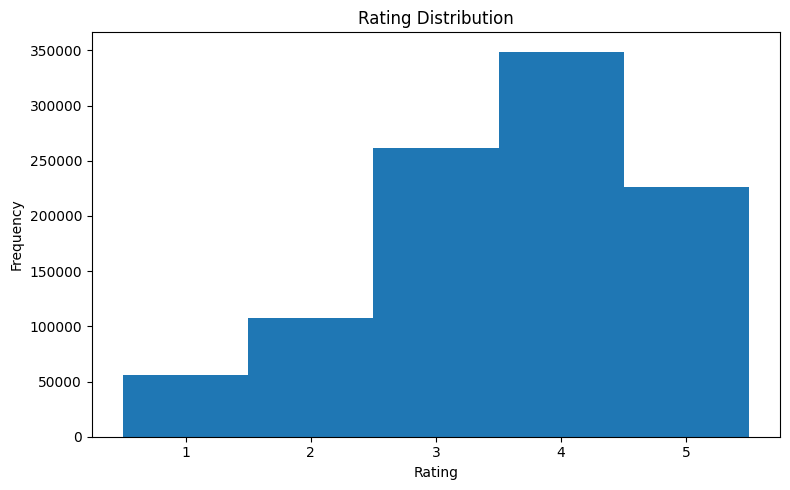

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_df['rating'], bins=np.arange( ratings_df['rating'].min(), ratings_df['rating'].max() + 2) - 0.5)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Rating Distribution")
plt.tight_layout()
plt.show()

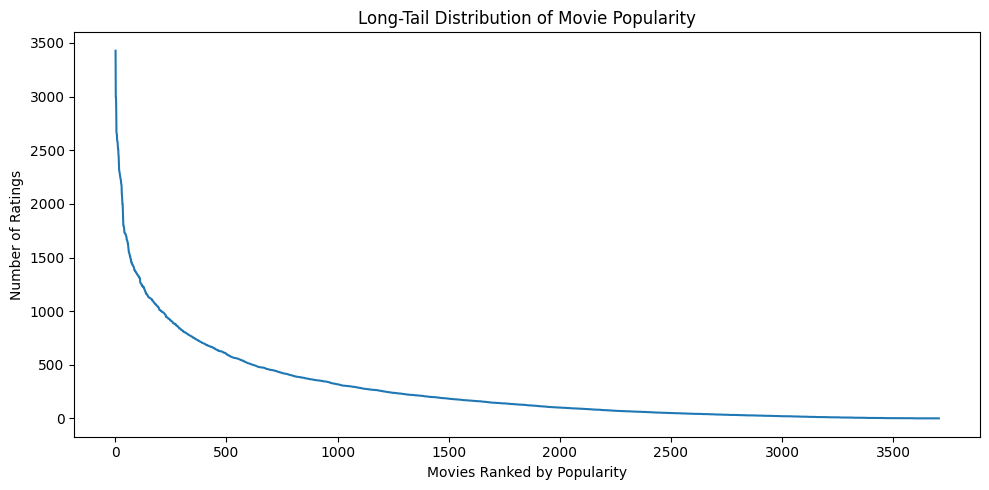

In [ ]:
movie_counts = (ratings_df.groupby('movieId').size().sort_values(ascending=False).to_numpy())
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(movie_counts) + 1), movie_counts)
plt.xlabel("Movies Ranked by Popularity")
plt.ylabel("Number of Ratings")
plt.title("Long-Tail Distribution of Movie Popularity")
plt.tight_layout()
plt.show()

##**Build Rating Matrix & Train-test Split**

In [ ]:
R, observed_mask, user_ids, movie_ids, user_id_to_index = build_rating_matrix(ratings_df)
print(R.shape)
R_train, train_mask, test_entries = create_train_test_split(R, observed_mask, test_size=0.2)
print(R_train.shape)

(6040, 3706)
(6040, 3706)


In [ ]:
R_initialized_user = initialize_missing_values(R_train, method='user')
R_normalized_user, user_means = normalize_matrix(R_initialized_user, method='user')
print(R_normalized_user.shape)
R_initialized_item = initialize_missing_values(R_train, method='item')
R_normalized_item, item_means = normalize_matrix(R_initialized_item, method='item')
print(R_normalized_item.shape)
print(len(test_entries))

(6040, 3706)


/tmp/ipykernel_5999/4245829939.py:72: RuntimeWarning: Mean of empty slice
  means = np.nanmean(R_filled, axis=0)


(6040, 3706)
200042


##**Select Rank k**

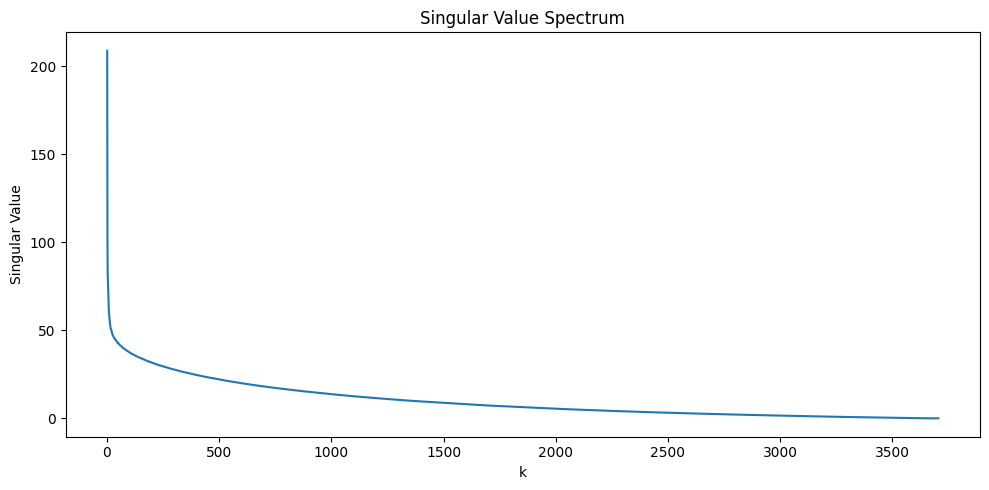

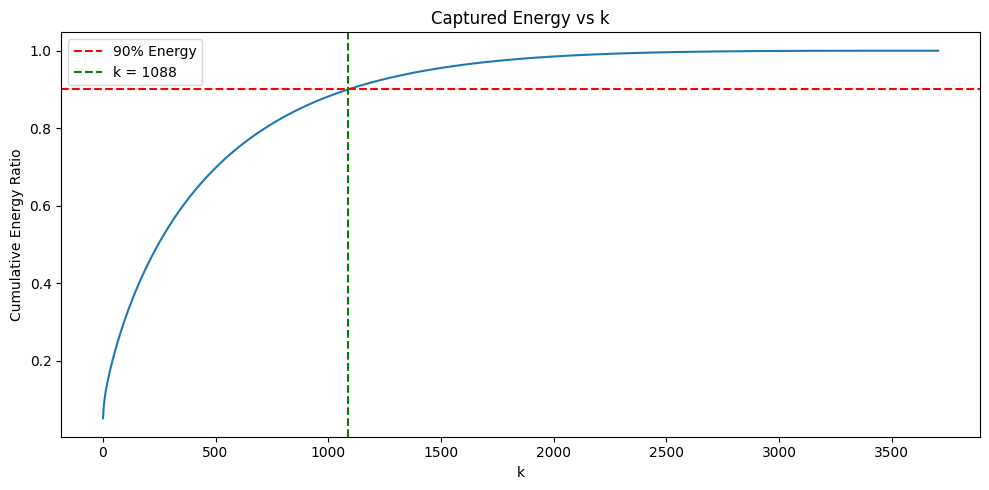

Chosen k = 1088
Captured energy = 90.01%


In [ ]:
k_user = analyze_singular_values(R_normalized_user, energy_threshold=ENERGY_THRESHOLD)

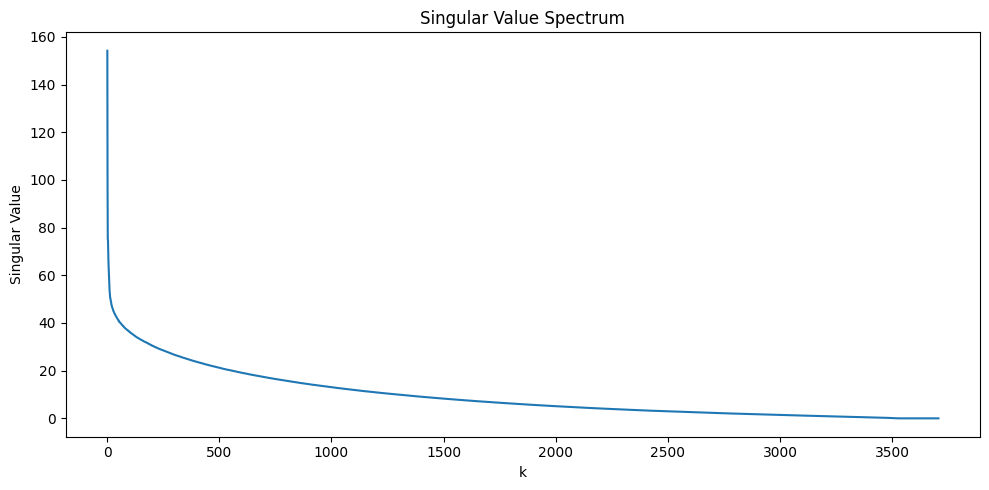

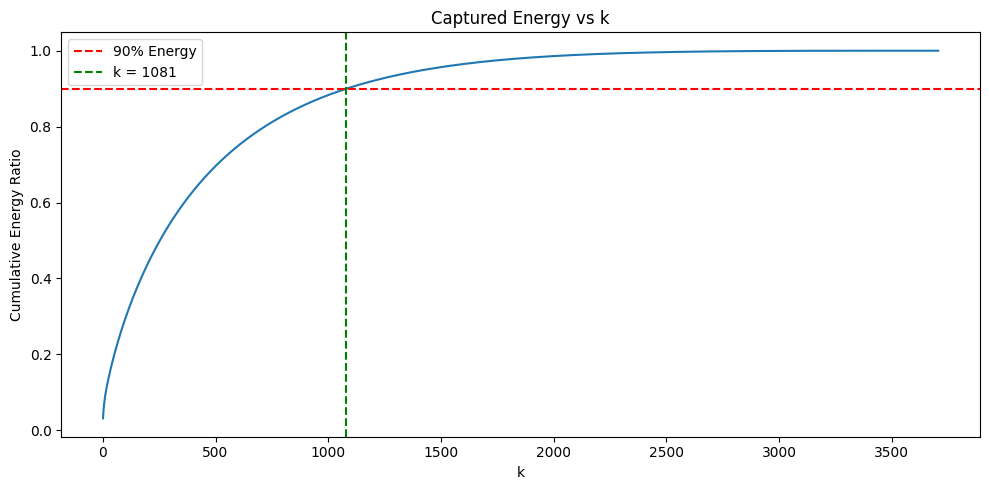

Chosen k = 1081
Captured energy = 90.00%


In [ ]:
k_item = analyze_singular_values(R_normalized_item, energy_threshold=ENERGY_THRESHOLD)

##**Train**

In [ ]:
R_completed_u, history_u = iterative_svd_completion(R_normalized_user, user_means, train_mask, k_user, normalization='user', epsilon=EPSILON, max_iter=MAX_ITER)

Chosen k = 1088
Captured energy = 90.01%
Using fixed k = 1088
Iteration   1 | Error = 0.96651156
Iteration   2 | Error = 0.33438014
Iteration   3 | Error = 0.18673553
Iteration   4 | Error = 0.16118459
Iteration   5 | Error = 0.12912338
Iteration   6 | Error = 0.10709669
Iteration   7 | Error = 0.09901129

Convergence reached.


In [ ]:
np.save('/content/drive/MyDrive/Bachelor Thesis/R_SVD_user_mean_full.npy', R_completed_u)

In [ ]:
R_completed_i, history_i = iterative_svd_completion(R_normalized_item, item_means, train_mask, k_item, normalization='item', epsilon=EPSILON, max_iter=MAX_ITER)

/tmp/ipykernel_434/1591593693.py:72: RuntimeWarning: Mean of empty slice
  means = np.nanmean(R_filled, axis=0)


Chosen k = 1081
Captured energy = 90.00%
Using fixed k = 1081
Iteration   1 | Error = 1.29169783
Iteration   2 | Error = 0.42529727
Iteration   3 | Error = 0.17119527
Iteration   4 | Error = 0.12812152
Iteration   5 | Error = 0.10245208
Iteration   6 | Error = 0.09085431

Convergence reached.


In [ ]:
np.save('/content/drive/MyDrive/Bachelor Thesis/R_SVD_item_mean_full.npy', R_completed_i)

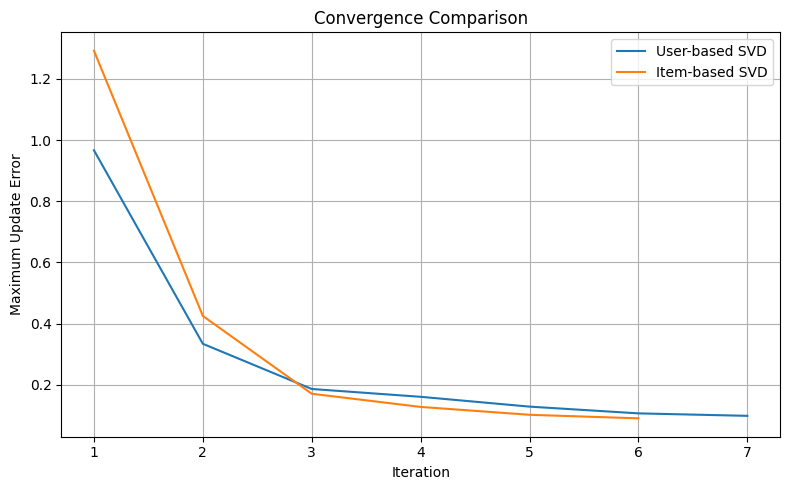

In [ ]:
plt.figure(figsize=(8,5))
plt.grid(True)
plt.plot(range(1, len(history_u) + 1), history_u, label='User-based SVD')
plt.plot(range(1, len(history_i) + 1), history_i, label='Item-based SVD')
plt.xlabel('Iteration')
plt.ylabel('Maximum Update Error')
plt.title('Convergence Comparison')
plt.legend()
plt.tight_layout()
plt.show()

##**Test**

In [ ]:
R_completed_u = np.load('/content/drive/MyDrive/Bachelor Thesis/R_SVD_user_mean_full.npy')
R_completed_i = np.load('/content/drive/MyDrive/Bachelor Thesis/R_SVD_item_mean_full.npy')

###**Evaluation**

In [ ]:
rmse_u, mae_u = evaluate_predictions(R_completed_u, test_entries)
rmse_i, mae_i = evaluate_predictions(R_completed_i, test_entries)
print('\nEvaluation Results')
print('-' * 30)
print("SVD with user-based normalization:")
print(f'RMSE = {rmse_u:.4f}')
print(f'MAE  = {mae_u:.4f}')
print('-' * 30)
print("SVD with item-based normalization:")
print(f'RMSE = {rmse_i:.4f}')
print(f'MAE  = {mae_i:.4f}')


Evaluation Results
------------------------------
SVD with user-based normalization:
RMSE = 1.0311
MAE  = 0.8259
------------------------------
SVD with item-based normalization:
RMSE = 0.9740
MAE  = 0.7772


###**Rating Prediction**

In [ ]:
user_id = 2
movie_id = 17

predicted_rating_u = predict_rating(R_completed_u, user_id, movie_id, user_id_to_index, movie_ids)
predicted_rating_i = predict_rating(R_completed_i, user_id, movie_id, user_id_to_index, movie_ids)
print(f'Predicted rating of user {user_id} 'f'for movie {movie_id}(user-based): {predicted_rating_u:.2f}')
print(f'Predicted rating of user {user_id} 'f'for movie {movie_id}(item-based): {predicted_rating_i:.2f}')

Predicted rating of user 2 for movie 17(user-based): 3.65
Predicted rating of user 2 for movie 17(item-based): 4.02


###**Recommendation Generation**

In [ ]:
example_user_id = int(user_ids[17])
recommendations_u = recommend_movies(R_completed_u, R, movie_ids, user_id=example_user_id, user_id_to_index=user_id_to_index, top_n=10)
recommendations_i = recommend_movies(R_completed_i, R, movie_ids, user_id=example_user_id, user_id_to_index=user_id_to_index, top_n=10)
movie_id_to_title = load_movie_titles_1m()

print(f'Top recommendations for user {example_user_id}:')
print('-' * 30)
print("SVD with user-based normalization:")
for rank, (movie_id, score) in enumerate(recommendations_u, start=1):
    title = movie_id_to_title.get(int(movie_id), "Unknown Title")
    title = prettify_title(title)
    print(f"{rank}. {title} ({score:.2f})")
print('-' * 30)
print("SVD with item-based normalization:")
for rank, (movie_id, score) in enumerate(recommendations_i, start=1):
    title = movie_id_to_title.get(int(movie_id), "Unknown Title")
    title = prettify_title(title)
    print(f"{rank}. {title} ({score:.2f})")

Top recommendations for user 18:
------------------------------
SVD with user-based normalization:
1. Dr. No (1962) (4.08)
2. Kagemusha (1980) (4.01)
3. Dangerous Beauty (1998) (4.00)
4. Exit to Eden (1994) (3.98)
5. For the Love of Benji (1977) (3.97)
6. The Jungle Book (1994) (3.95)
7. The Brain That Wouldn't Die (1962) (3.95)
8. Beautiful Girls (1996) (3.95)
9. Moll Flanders (1996) (3.94)
10. The Big Kahuna (2000) (3.93)
------------------------------
SVD with item-based normalization:
1. Schlafes Bruder (Brother of Sleep) (1995) (5.00)
2. The Gate of Heavenly Peace (1995) (5.00)
3. Lured (1947) (5.00)
4. Bittersweet Motel (2000) (5.00)
5. One Little Indian (1973) (5.00)
6. Identification of a Woman (Identificazione di una donna) (1982) (5.00)
7. The Baby (1973) (5.00)
8. Smashing Time (1967) (5.00)
9. Ulysses (Ulisse) (1954) (5.00)
10. Kagemusha (1980) (4.71)


In [ ]:
example_user_id = int(user_ids[1110])
recommendations_u = recommend_movies(R_completed_u, R, movie_ids, user_id=example_user_id, user_id_to_index=user_id_to_index, top_n=10)
recommendations_i = recommend_movies(R_completed_i, R, movie_ids, user_id=example_user_id, user_id_to_index=user_id_to_index, top_n=10)
movie_id_to_title = load_movie_titles_1m()

print(f'Top recommendations for user {example_user_id}:')
print('-' * 30)
print("SVD with user-based normalization:")
for rank, (movie_id, score) in enumerate(recommendations_u, start=1):
    title = movie_id_to_title.get(int(movie_id), "Unknown Title")
    title = prettify_title(title)
    print(f"{rank}. {title} ({score:.2f})")
print('-' * 30)
print("SVD with item-based normalization:")
for rank, (movie_id, score) in enumerate(recommendations_i, start=1):
    title = movie_id_to_title.get(int(movie_id), "Unknown Title")
    title = prettify_title(title)
    print(f"{rank}. {title} ({score:.2f})")

Top recommendations for user 1111:
------------------------------
SVD with user-based normalization:
1. An American Tail (1986) (4.40)
2. Thumbelina (1994) (4.39)
3. D3: The Mighty Ducks (1996) (4.35)
4. Anastasia (1997) (4.34)
5. Bad Boys (1995) (4.32)
6. Condorman (1981) (4.32)
7. To Sir with Love (1967) (4.32)
8. Oliver & Company (1988) (4.31)
9. The Fly (1958) (4.30)
10. Flipper (1996) (4.30)
------------------------------
SVD with item-based normalization:
1. Schlafes Bruder (Brother of Sleep) (1995) (5.00)
2. The Gate of Heavenly Peace (1995) (5.00)
3. One Little Indian (1973) (5.00)
4. Smashing Time (1967) (5.00)
5. Ulysses (Ulisse) (1954) (5.00)
6. Identification of a Woman (Identificazione di una donna) (1982) (5.00)
7. The Baby (1973) (5.00)
8. Lured (1947) (5.00)
9. Bittersweet Motel (2000) (5.00)
10. Lamerica (1994) (4.74)
